In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm.auto import tqdm
import cvxpy as cp
import warnings
warnings.filterwarnings('ignore')

root        = '../'
data_file   = '03_data/data_for_experiments/'
output_file = '05_output/'
start_date  = '200101'
end_date    = '202412'
created_small_sample = False

os.makedirs(root + output_file, exist_ok=True)

In [44]:
if created_small_sample:
    # creat small data samples
    root        = '../'
    data_file   = '03_data/'

    all_signals = pd.read_parquet(root + data_file + 'WRDS/all_signals.parquet')
    all_signals.rename(columns={'yyyymm': 'date'}, inplace=True)
    all_signals['date'] = all_signals['date'].astype(str)
    all_signals = all_signals[(all_signals['date'] >= start_date) & (all_signals['date'] <= end_date)]
    os.makedirs(root + data_file + 'data_for_experiments/', exist_ok=True)
    all_signals.to_pickle(root + data_file + 'data_for_experiments/all_signals.pickle')
    del all_signals
    print('signals done')

    crsp_d = pd.read_parquet(root + data_file + 'WRDS/crsp_d.parquet')
    crsp_d = crsp_d[(crsp_d['date'] >= start_date[:4] + '-' + start_date[4:] + '-01') & (crsp_d['date'] <= end_date[:4] + '-' + end_date[4:] + '-31')]
    crsp_d.reset_index(drop=True, inplace=True)
    crsp_d.to_pickle(root + data_file + 'data_for_experiments/stock_daily.pickle')
    del crsp_d
    print('stock done')

In [45]:
import wrds
db = wrds.Connection(wrds_username = 'dunran')
sp500list = db.raw_sql("SELECT * FROM crsp.dsp500list")

Loading library list...
Done


In [46]:
signals = pd.read_pickle(root + data_file + 'all_signals.pickle')

In [47]:
# generate monthly return data from daily return
stock_daily = pd.read_pickle(root + data_file + 'stock_daily.pickle')
stock_daily = stock_daily[stock_daily['permno'].isin(sp500list['permno'].tolist())]
stock_daily['month'] = stock_daily['date'].apply(lambda x: x[:7])
stock_daily.sort_values(by=['permno', 'date'], inplace=True)
stock_monthly = stock_daily.groupby(['permno', 'month']).agg(
    ret       = ('ret',    'sum'),
    prc       = ('prc',    'last'),
    shrout    = ('shrout', 'last'),
    vol       = ('vol',    'sum'),
    shrcd     = ('shrcd',  'last'),
    exchcd    = ('exchcd', 'last'),
).reset_index()
stock_monthly['date'] = stock_monthly['month'].apply(lambda x: x.split('-')[0] + x.split('-')[1])
stock_monthly = stock_monthly[['permno', 'date', 'ret', 'prc', 'shrout', 'vol', 'shrcd', 'exchcd']]
os.makedirs(root + output_file + 'stock_monthly/', exist_ok=True)
stock_monthly.to_pickle(root + output_file + 'stock_monthly/stock_monthly.pickle')

In [48]:
stock_monthly = pd.read_pickle(root + output_file + 'stock_monthly/stock_monthly.pickle')
stock_monthly = stock_monthly.sort_values(by=['permno', 'date']).reset_index(drop=True)
stock_monthly['ret_f1'] = stock_monthly.groupby(['permno'])['ret'].shift(-1)
stock_monthly = stock_monthly.merge(
    right = signals,
    on    = ['permno', 'date'],
    how   = 'left',
)
cutoff_level = 0.1
stock_monthly = stock_monthly.loc[:, stock_monthly.isnull().mean() <= cutoff_level].dropna(axis=0)

In [49]:
# for i in range(1, 10):
#     print(f'cut in {i*0.01:.2f} generates {stock_monthly.loc[:, stock_monthly.isnull().mean() <= i*0.01].dropna(axis = 0)['permno'].nunique():5} stocks')

In [50]:
def Equal_Weighted(returns_array):
    n_stocks = returns_array.shape[1]
    weight = 1.0 / n_stocks
    weights_col_vector = np.full((n_stocks, 1), weight)
    return weights_col_vector

def DRMV(returns, alpha_bar = 0.10 / 12, delta = 0.1, p = 2):
    n, d = returns.shape
    mu = np.mean(returns, axis=0)
    Sigma = returns.T @ returns / n
    V = Sigma - np.outer(mu, mu)
    
    def objective(phi):
        var_term = np.sqrt(phi.T @ V @ phi)
        reg_term = np.sqrt(delta) * np.linalg.norm(phi, ord=p)
        return float(var_term + reg_term)
    
    cons = [
        {'type': 'eq',   'fun': lambda phi: np.sum(phi) - 1.0},
        {'type': 'ineq', 'fun': lambda phi: mu @ phi - (alpha_bar + np.sqrt(delta) * np.linalg.norm(phi, ord=p))}
    ]
    
    res = minimize(objective, x0=np.ones(d)/d, method='SLSQP', constraints=cons,
        options={'disp': False, 'maxiter': 500, 'ftol': 1e-9},
        tol=1e-9
    )
    
    weights = res.x.reshape(-1, 1)
    weights = weights / np.sum(weights)
    return weights

In [90]:
DATE = stock_monthly['date'].sort_values().unique()
BACKTEST_START = DATE.min() 
BACKTEST_END   = '202412'
print(f'back test happens between {BACKTEST_START} and {BACKTEST_END}')
strategies = ['Single_Period_Markowitz', 'Equal_Weighted'] + [f'DRMV_\delta=1e-{i}' for i in range(1, 8)]
port_ret = {s: [] for s in strategies}

data = stock_monthly.pivot(index='date', columns='permno', values='ret')
data = data.sort_index()

back test happens between 200101 and 202412


In [ ]:
for i, date in enumerate(DATE):
    if i + 120 + 1 >= len(DATE) or DATE[i+121] > BACKTEST_END:
        break
    print('\r', DATE[i+121], end = '')
    data_pool = data.iloc[i : i + 120 + 1].dropna(axis=1)
    temp_sum = {s: 0.0 for s in strategies}
    num_samples = 10
    
    for s in range(num_samples):
        data_cut = data_pool.sample(20, axis=1, random_state=s).values
        train_data = data_cut[:-1, :]
        test_data  = data_cut[-1:, :]
        
        w_ew = Equal_Weighted(train_data)
        temp_sum['Equal_Weighted'] += (test_data @ w_ew)[0]
        
        w_spm = DRMV(train_data, 0.1/12, 0)
        temp_sum['Single_Period_Markowitz'] += (test_data @ w_spm)[0]
        
        for j in range(1, 8):
            key = f'DRMV_\delta=1e-{j}'
            w_drvm = DRMV(train_data, 0.1/12, 10**(-j))
            temp_sum[key] += (test_data @ w_drvm)[0]
            
    for s in strategies:
        port_ret[s].append(temp_sum[s] / num_samples)

 201103

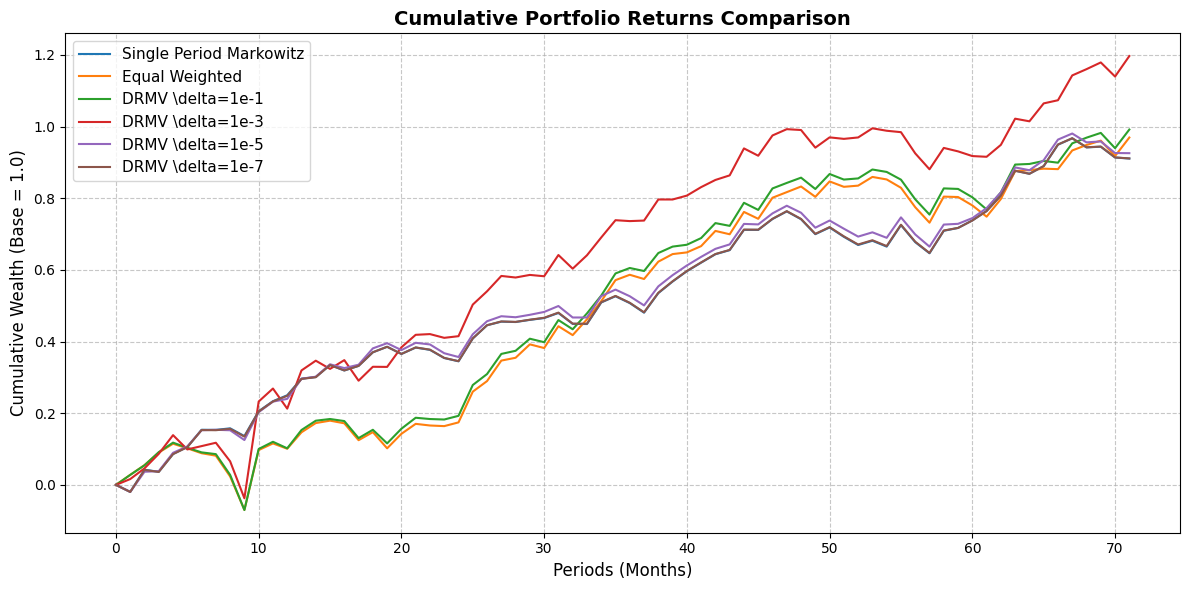

In [ ]:
plt.figure(figsize=(12, 6), dpi=100)
for strategy_name, returns_list in port_ret.items():
    # if strategy_name in ['DRMV_\delta=1e-1', 'DRMV_\delta=1e-3']:
    #     continue
    returns_array = np.array(returns_list).flatten()
    cumulative_returns = np.cumsum(returns_array)
    cumulative_returns = np.insert(cumulative_returns, 0, 0)
    plt.plot(cumulative_returns, label=strategy_name.replace('_', ' '), linewidth=1.5)

plt.title('Cumulative Portfolio Returns Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Periods (Months)', fontsize=12)
plt.ylabel('Cumulative Wealth (Base = 1.0)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_ret = pd.DataFrame({
    k: np.ravel(v) for k, v in port_ret.items() if len(v) > 0
})

df_ret.index = pd.to_datetime(DATE[120:120+df_ret.shape[0]], format='%Y%m')

annual_rf = 0.02
months_in_year = 12

stats = pd.DataFrame(index=df_ret.columns)

# 年化算术平均收益
stats['Annualized Mean'] = df_ret.mean() * months_in_year

# 年化标准差 (风险)
stats['Annualized Volatility'] = df_ret.std() * np.sqrt(months_in_year)

# 年化夏普比率
stats['Sharpe Ratio'] = (stats['Annualized Mean'] - annual_rf) / stats['Annualized Volatility']

annual_returns_table = df_ret.groupby(df_ret.index.year).apply(lambda x: (x).sum())

# --- 4. 格式化输出 ---
print("----- 策略表现统计 (年化) -----")
print(stats.round(4))

print("\n----- 分年回报率 (年度累积) -----")
# 转置后行是方法，列是年份，更符合论文或报告格式
print(annual_returns_table.T.round(4))



----- 策略表现统计 (年化) -----
                        Annualized Mean Annualized Volatility Sharpe Ratio
Single_Period_Markowitz        0.153947              0.103104      1.29915
Equal_Weighted                 0.163866              0.138562     1.038281
DRMV_\delta=1e-1               0.167639              0.140309     1.052239
DRMV_\delta=1e-3               0.202312              0.170417     1.069796
DRMV_\delta=1e-5               0.156487              0.104096     1.311172
DRMV_\delta=1e-7               0.154017              0.103115     1.299692

----- 分年回报率 (年度累积) -----
                           2011    2012    2013    2014    2015    2016
Single_Period_Markowitz  0.2502  0.0948  0.1624  0.2341 -0.0032  0.1725
Equal_Weighted           0.1009  0.0735  0.4121  0.2463 -0.0527  0.1894
DRMV_\delta=1e-1         0.1021  0.0907  0.4126  0.2521 -0.0548  0.1891
DRMV_\delta=1e-3         0.2128  0.2023  0.3212  0.2542 -0.0727  0.2792
DRMV_\delta=1e-5         0.2401  0.1168  0.1696  0.2331 -0.0150  